---
title: "Lecture 8: Cholesky factorization"
author: "Jamie Haddock"
format: 
    revealjs:
        output-file: Lecture8_slides
        slide-number: true
        preview-links: auto
        logo: figs/hmc.png
        css: input/slides.css
        incremental: true
        smaller: true
        code-fold: true
        embed-resources: true
        html-math-method: mathjax
    html: 
        output-file: Lecture8
        code-fold: true
        embed-resources: true
        code-links:
        - text: "Open in Colab"
          href: "https://colab.research.google.com/github/jamiehadd/Math-189M-NumericalLinearAlgebra/blob/main/Lecture8_Cholesky_factorization.ipynb"
          icon: "laptop"
    pdf:
        output-file: Lecture8
        documentclass: article
        toc: true
        number-sections: true
        geometry:
          - top=1in
          - left=1in
          - bottom=1in
          - right=1in
format-links: false
jupyter: julia-1.9
colab:
  gh-user: "jamiehadd"   
  gh-repo: "Math-189M-NumericalLinearAlgebra" 
filters: 
  - input/remove-pause.lua
  - colab
execute:
  echo: true
  eval: true
---

<!--
[verbose test]{.content-hidden when-format="revealjs" when-format="pptx"}

::: {.callout-caution icon=false}
## Exercise: 

:::

<details><summary>Answer:</summary> </details>


::: {.callout-note icon=false}
## Definition: 
 
:::


::: {.callout-tip icon=false}
## Note: 
 
:::
-->

# Cholesky Factorization

## Motivation

- Recall: general LU factorization costs $\mathcal{O}(n^3)$ flops, and row pivoting is needed for numerical stability.
- Many matrices that arise in practice are **symmetric positive definite (SPD)**:
  - Normal equations $\mathbf{A}^\top \mathbf{A}$ from least squares
  - Gram matrices and sample covariance matrices
  - Stiffness/mass matrices from discretized PDEs (e.g. the 1D/2D Poisson equation)
  - Kernel matrices in Gaussian processes and kernel methods

. . .

**Question:** if $\mathbf{A}$ has extra structure &mdash; symmetry *and* positive definiteness &mdash; can we exploit it to do less work than LU, and can we avoid pivoting altogether?

. . .

**Answer:** Yes!  The algorithm requires roughly **half the flops**, and **no pivoting is ever needed**.

---

## Recall: Symmetric Positive Definite Matrices

::: {.callout-note icon=false}
## Definition: Positive definite matrix
A symmetric matrix $\mathbf{A}$ is **positive definite** if
$$
x^\top \mathbf{A} x > 0 \qquad \text{for every nonzero } x \in \mathbb{R}^n.
$$
:::

. . .

We call $\mathbf{A}$ **symmetric positive definite (SPD)** if it is both positive definite and symmetric.

Useful equivalent characterizations of positive definiteness:

- Every eigenvalue of $\mathbf{A}$ is positive. (Proving equivalence is a homework problem.)
- Every **leading principal minor** of $\mathbf{A}$ is positive.
- Every leading principal submatrix of $\mathbf{A}$ is itself SPD.

. . .

[The $k$th leading principal minor is $\det(\mathbf{A}_{1:k,\,1:k})$, the determinant of the top-left $k\times k$ block, the leading principal submatrix.]{.content-hidden when-format='revealjs' when-format='pptx'}

---

You can check the leading principal minors to determine if a matrix is SPD.

In [60]:
using LinearAlgebra
B = [2 -1 0; -1 2 -1; 0 -1 2]

3×3 Matrix{Int64}:
  2  -1   0
 -1   2  -1
  0  -1   2

In [61]:
det(B[1:1,1:1]), det(B[1:2,1:2]), det(B[1:3,1:3])

(2.0, 3.0, 4.0)

. . .

All three leading principal minors are positive, so $\mathbf{B}$ is SPD.

In [62]:
isposdef(B)

true

---

## Deriving the Cholesky Factorization

::: {.callout-warning icon=false}
## Theorem: Cholesky factorization
Any SPD matrix $\mathbf{A} \in \mathbb{R}^{n\times n}$ may be factored as $$\mathbf{A} = \mathbf{R}^\top \mathbf{R},$$ where $\mathbf{R} \in \mathbb{R}^{n\times n}$ is an upper triangular matrix with positive diagonal elements.  This is called the **Cholesky factorization**.
:::

. . . 

Just like `lufact`, we build $\mathbf{R}$ one row at a time by outer-product deflation:

- Peel off the first row: $R_{11} = \sqrt{A_{11}}$, and the rest of the first row is $R_{1,2:n} = A_{1,2:n}/R_{11}.$
- Update the trailing $(n-1)\times(n-1)$ block by subtracting the rank-one outer product contribution: $A_{2:n,2:n} \leftarrow A_{2:n,2:n} - R_{1,2:n}^\top R_{1,2:n}$.
- Recurse on the (symmetric, one-smaller) trailing block.

. . .

At every step, computing the next diagonal entry of $\mathbf{R}$ requires a square root &mdash; so the algorithm can only proceed if the quantity under each square root is positive.

---

In the homework, you'll dig into why that's guaranteed when $\mathbf{A}$ is SPD, and can fail when $\mathbf{A}$ is merely symmetric.

---

## The `cholfact` Algorithm

In [63]:
"""
    cholfact(A)

Compute the Cholesky factorization of a symmetric positive definite matrix `A`,
returning the upper triangular factor `R` such that `A ≈ R'*R`.
"""
function cholfact(A)
    n = size(A,1)
    R = zeros(n,n)
    Ak = float(copy(A))  # will be overwritten at each step

    for k in 1:n
        akk = Ak[k,k]
        @assert akk > 0 "matrix is not positive definite"
        R[k,k] = sqrt(akk)
        v = Ak[k,k+1:n] / R[k,k]
        R[k,k+1:n] = v
        Ak[k+1:n,k+1:n] -= v*v'
    end
    return UpperTriangular(R)
end

cholfact

---

Let's walk through this by hand on a small SPD example.

In [64]:
A₁ = [
    4   2  -2
    2  10   2
   -2   2   5
]
isposdef(A₁)

true

[Since $R_{11}=\sqrt{a_{11}}$, the rest of row 1 is $A_{1,2:3}/R_{11}$:]{.content-hidden when-format='revealjs' when-format='pptx'}

In [65]:
R = zeros(3,3)
R[1,1] = sqrt(A₁[1,1])
R[1,2:3] = A₁[1,2:3]/R[1,1]
R

3×3 Matrix{Float64}:
 2.0  1.0  -1.0
 0.0  0.0   0.0
 0.0  0.0   0.0

In [66]:
A₂ = A₁[2:3,2:3] - R[1,2:3]*R[1,2:3]'

2×2 Matrix{Float64}:
 9.0  3.0
 3.0  4.0

---

[Now repeat on the trailing $2\times 2$ block $\mathbf{A}_2$:]{.content-hidden when-format='revealjs' when-format='pptx'}

In [67]:
R[2,2] = sqrt(A₂[1,1])
R[2,3] = A₂[1,2]/R[2,2]
A₃ = A₂[2,2] - R[2,3]^2

3.0

In [68]:
R[3,3] = sqrt(A₃)
R = UpperTriangular(R)

3×3 UpperTriangular{Float64, Matrix{Float64}}:
 2.0  1.0  -1.0
  ⋅   3.0   1.0
  ⋅    ⋅    1.73205

In [69]:
A₁ - R'*R

3×3 Matrix{Float64}:
 0.0  0.0  0.0
 0.0  0.0  0.0
 0.0  0.0  0.0

. . .

Compared to `lufact`:

- One loop and one factor ($\mathbf{R}$) instead of two ($\mathbf{L}$ and $\mathbf{U}$).
- The symmetric rank-one update `v*v'` replaces the two-sided outer product `L[:,k]*U[k,:]'`.
- The `@assert` doubles as a SPD *test*: if it ever fails, $\mathbf{A}$ was not SPD.

---

## Computational Cost

::: {.callout-warning icon=false}
## Theorem: Efficiency of Cholesky factorization
Cholesky factorization of an $n\times n$ SPD matrix takes $\mathcal{O}(n^3/3)$ flops as $n \to \infty$ &mdash; about **half** the cost of general LU factorization ($\mathcal{O}(2n^3/3)$ flops).
:::

[Roughly: at step $k$, updating the trailing $(n-k)\times(n-k)$ block costs about $(n-k)^2$ flops, and $\sum_{k=1}^n (n-k)^2 \approx n^3/3$. LU does a comparable update *twice* &mdash; once for $\mathbf{L}$'s column, once for $\mathbf{U}$'s row &mdash; so it costs about twice as much.]{.content-hidden when-format='revealjs' when-format='pptx'}

In [77]:
M = randn(3,3);
cholesky(Symmetric(M*M' + 3I)); lu(M); #throwaway to force compilation

ns = 400:400:4000
t_chol, t_lu = [], []
for n in ns
    M = randn(n,n)
    A = M*M' + n*I   # a well-conditioned SPD test matrix

    time_chol = @elapsed for j in 1:12; cholesky(A); end
    push!(t_chol, time_chol)

    time_lu = @elapsed for j in 1:12; lu(A); end
    push!(t_lu, time_lu)
end

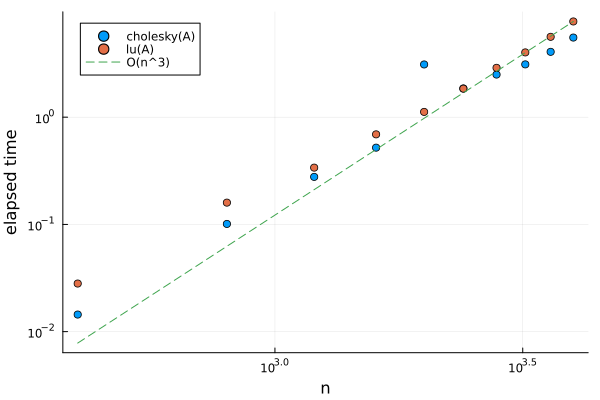

In [78]:
using Plots

scatter(ns, t_chol, label="cholesky(A)", legend=:topleft,
    xaxis=(:log10,"n"), yaxis=(:log10,"elapsed time"))
scatter!(ns, t_lu, label="lu(A)")
plot!(ns, t_lu[end]*(ns/ns[end]).^3, l=:dash, label="O(n^3)")

---

Both curves scale like $n^3$, but `cholesky` has roughly half the constant of `lu`. In practice, use the built-in `cholesky(A)` from `LinearAlgebra`; just like `lu`/`\`.

## Alternative Derivation of Cholesky

In the homework, you'll work through an entry-wise centric derivation of the Cholesky factorization.  One can instead see the factorization through a matrix factorization lens:

. . .

After the first step of the algorithm, the matrix $\mathbf{R}$ shares the same first row as $\tilde{\mathbf{R}}$, which satisfies: $$\mathbf{A} = \begin{bmatrix} \sqrt{A_{11}} & \mathbf{0}^\top \\ \frac{1}{\sqrt{A_{11}}}\mathbf{A}_{1,2:n}^\top & \mathbf{I} \end{bmatrix} \begin{bmatrix} 1 & \mathbf{0}^\top \\ \mathbf{0} & \mathbf{A}_{2:n,2:n} - \frac{1}{A_{11}}\mathbf{A}_{1,2:n}^\top \mathbf{A}_{1,2:n} \end{bmatrix} \begin{bmatrix} \sqrt{A_{11}} & \frac{1}{\sqrt{A_{11}}}\mathbf{A}_{1,2:n} \\ \mathbf{0} & \mathbf{I} \end{bmatrix}$$ where $\tilde{\mathbf{R}} = \begin{bmatrix} \sqrt{A_{11}} & \frac{1}{\sqrt{A_{11}}}\mathbf{A}_{1,2:n} \\ \mathbf{0} & \mathbf{I} \end{bmatrix}.$

. . .

The algorithm progresses, filling rows of $\mathbf{R}$ and $\tilde{\mathbf{R}}$ until the middle matrix is $\mathbf{I}$.  

---

One can show using induction that this process works using the following lemma.

::: {.callout-warning icon=false}
## Lemma:
If $\mathbf{A}$ is SPD and $\mathbf{B}$ is non-singular, then $\mathbf{B}^\top \mathbf{A}\mathbf{B}$ is also SPD.
:::

. . .

Applying this with $\tilde{\mathbf{R}}^{-1}$ yields that $\mathbf{A}_{2:n,2:n} - \frac{1}{A_{11}}\mathbf{A}_{1,2:n}^\top$ is SPD. 

---

Note that the matrix $\mathbf{A}_{2:n,2:n} - \frac{1}{A_{11}}\mathbf{A}_{1,2:n}^\top$ is called the Schur complement of entry $A_{11}$ in $\mathbf{A}$.

::: {.callout-note icon=false}
## Definition: Schur complement
Assume $$\mathbf{A} = \begin{bmatrix} \mathbf{A}_{11} & \mathbf{A}_{12} \\ \mathbf{A}_{21} & \mathbf{A}_{22} \end{bmatrix}$$ is given in $2 \times 2$ block form.  Then $$\mathbf{A}_{22} - \mathbf{A}_{21} \mathbf{A}_{11}^{-1} \mathbf{A}_{12}$$ is called the **Schur complement** of $\mathbf{A}_{11}$ for matrix $\mathbf{A}$.
:::

. . .

If $\mathbf{A}$ is SPD, then the Schur complement of $\mathbf{A}_{11}$ is also SPD.


---

## No Pivoting Needed: Stability

Recall our previous example: unpivoted LU on $\begin{bmatrix} -\epsilon & 1 \\ 1 & -1 \end{bmatrix}$ lost almost all accuracy as $\epsilon \to 0$, because it divided by a tiny pivot. Row pivoting (PLU) fixed it completely.


::: {.callout-warning icon=false}
## Fact: unconditional stability of Cholesky
Cholesky factorization of an SPD matrix is **backward stable, with no pivoting required.**
:::

. . .

As with the previous example, let's separate the algorithm's stability from the *problem's* conditioning:

In [72]:
n = 10
H = [1/(i+j-1) for i in 1:n, j in 1:n]   # the n×n Hilbert matrix
isposdef(H), cond(H)

(true, 1.602489743907797e13)

In [73]:
R = cholfact(H)
norm(H - R'*R)

5.679729445007588e-17

---

Even though $\mathbf{H}$ is severely ill-conditioned (its condition number is enormous), Cholesky still runs to completion and returns a tiny residual &mdash; the *algorithm* is stable even when the *problem* is ill-conditioned.

A large residual is not automatically evidence of an unstable algorithm -- it can just as well be an ill-conditioned problem. Here, despite the ill-conditioning, Cholesky handles $\mathbf{H}$ just fine.  It's *solving a system with* $\mathbf{H}$ that becomes sensitive to error as $\kappa(\mathbf{H})$ grows.

In [74]:
b = H*ones(n);
z = FNC.forwardsub(Matrix(R)', b)
x = FNC.backsub(Matrix(R), z)
norm(x - ones(n))

9.479605673924518e-5

---

## Solving Linear Systems with Cholesky

We can solve $\mathbf{A}x = b$ in three steps, just as with LU:

1. Factor $\mathbf{A} = \mathbf{R}^\top\mathbf{R}$.
2. Solve $\mathbf{R}^\top z = b$ for $z$ using forward substitution (since $\mathbf{R}^\top$ is lower triangular).
3. Solve $\mathbf{R} x = z$ for $x$ using backward substitution (since $\mathbf{R}$ is upper triangular).

. . .

Once $\mathbf{R}$ is computed, solving for additional right-hand sides costs only $\mathcal{O}(n^2)$ each &mdash; the same reuse benefit as LU.

In [75]:
using FundamentalsNumericalComputation

R = cholfact(A₁)
b = rand(3)
z = FNC.forwardsub(Matrix(R)', b)
x = FNC.backsub(R, z)

3-element Vector{Float64}:
  0.21740121365988105
 -0.0864022588826147
  0.28138031434223865

In [76]:
b - A₁*x

3-element Vector{Float64}:
  0.0
  5.551115123125783e-17
 -1.1102230246251565e-16

---

## Applications 

- **Normal equations for least squares:** solving $\min_x \|\mathbf{A}x-b\|_2$ leads to $\mathbf{A}^\top\mathbf{A}x = \mathbf{A}^\top b$; when $\mathbf{A}$ has full column rank, $\mathbf{A}^\top\mathbf{A}$ is SPD, so Cholesky is a standard way to solve least-squares problems.
  - **Caveat:** squaring $\mathbf{A}$ worsens conditioning, $\kappa(\mathbf{A}^\top\mathbf{A}) = \kappa(\mathbf{A})^2$ -- we'll have need for another strategy for these problems.
- **Covariance/kernel matrices:** sampling multivariate normal random vectors, Gaussian process regression.
- **PDE discretizations:** stiffness and mass matrices from finite element/finite difference methods.
- **Interior-point methods:** solving an SPD linear system at every iteration.

. . .

[We'll see a full worked numerical example of Cholesky applied to the normal equations in an upcoming lecture, when we return to linear least squares.]{.content-hidden when-format='revealjs' when-format='pptx'}